# Extração de regras de detectores de anomalia com TF-IDF

Detectores de anomalia (Isolation Forest, One-Class SVM e LOF) usando **somente TF-IDF do texto**,
sem as features estilométricas nem `tem_autor`. Cada detector é explicado por uma **árvore de
decisão substituta** sobre termos TF-IDF: cada caminho vira uma regra do tipo
"SE contém 'X' E não contém 'Y' → alerta".

- Detectores: TF-IDF e modelo ajustados **somente com `normalTrain`** (True); q95 calibrado nas True
  de validação; candidato escolhido na validação (ROC-AUC → AP → desempate).
- Árvore substituta: alvo = **alerta q95 do detector**, não o label. Ajustada na validação;
  **fidelidade** (concordância com o detector) medida uma única vez no teste.
- O label real aparece só como descrição: taxa de Fake entre as notícias cobertas por cada regra.

## Importando os dados preparados

In [1]:
import joblib

partitions, anomalyColumns = joblib.load("./dados_preparados.pkl")

## Imports

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier, plot_tree

from anomaly_utils import anomalyScores, binaryMetrics, combinePartitions, scoreSummary, selectCandidate

RANDOM_STATE = 42
TEXT_COLUMN = "text"

# Detectores com TF-IDF

Mesmo prefixo de `CHARACTER_LIMIT` caracteres (`text`) do 01_Data_Prep, então o comprimento original
não vaza. TF-IDF de palavras com unigramas e bigramas, como o `txt_word` dos notebooks
supervisionados, com vocabulário aprendido só nas True de treino.

- `IF` - Isolation Forest com 300 árvores (candidato único)
- `OCSVM` - One-Class SVM RBF com `nu` ∈ {0.01, 0.025, 0.05, 0.10}
- `LOF` - Local Outlier Factor (`novelty=True`, distância cosseno) com `n_neighbors` ∈ {10, 20, 40, 80}

In [3]:
def buildTfidfPipeline(detector):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, token_pattern=r"(?u)\b[^\d\W]{2,}\b")),
        ("detector", detector),
    ])


candidateFamilies = {
    "IF": {
        "if_trees_300": buildTfidfPipeline(IsolationForest(n_estimators=300, contamination="auto", random_state=RANDOM_STATE, n_jobs=-1)),
    },
    "OCSVM": {
        key: buildTfidfPipeline(OneClassSVM(kernel="rbf", gamma="scale", nu=nu))
        for key, nu in {"ocsvm_nu_001": 0.01, "ocsvm_nu_0025": 0.025, "ocsvm_nu_005": 0.05, "ocsvm_nu_010": 0.10}.items()
    },
    "LOF": {
        f"lof_neighbors_{neighbors:03d}": buildTfidfPipeline(
            LocalOutlierFactor(n_neighbors=neighbors, metric="cosine", contamination="auto", novelty=True, n_jobs=1)
        )
        for neighbors in [10, 20, 40, 80]
    },
}
tieBreakers = {"IF": "modelKey", "OCSVM": "modelKey", "LOF": "modelKey"}
{family: list(candidates) for family, candidates in candidateFamilies.items()}

{'IF': ['if_trees_300'],
 'OCSVM': ['ocsvm_nu_001', 'ocsvm_nu_0025', 'ocsvm_nu_005', 'ocsvm_nu_010'],
 'LOF': ['lof_neighbors_010',
  'lof_neighbors_020',
  'lof_neighbors_040',
  'lof_neighbors_080']}

`fitNormalOnly` do `anomaly_utils` verifica o imputer das features numéricas, que não existe
nestes pipelines de texto. A função abaixo aplica o mesmo contrato (só True no fit, IDs do fit
bloqueados para pontuação) e reaproveita `anomalyScores`/`binaryMetrics` do módulo.

In [4]:
def fitNormalOnlyText(pipeline, trainingFrame):
    if trainingFrame.empty or not trainingFrame["label"].eq(0).all():
        raise ValueError("Treino permitido apenas com notícias True (label == 0).")
    if trainingFrame[TEXT_COLUMN].isna().any():
        raise ValueError("Textos ausentes em normalTrain.")
    pipeline.fit(trainingFrame[TEXT_COLUMN])
    pipeline._normalTrainIds = frozenset(trainingFrame["id"].astype(str))
    return pipeline


validationFrame = combinePartitions(partitions, "Validation")
testFrame = combinePartitions(partitions, "Test")
validationLabels = validationFrame["label"].to_numpy(dtype=int)
testLabels = testFrame["label"].to_numpy(dtype=int)

fittedPipelines, records = {}, []
for family, candidates in candidateFamilies.items():
    for modelKey, pipeline in candidates.items():
        fitStarted = time.perf_counter()
        pipeline = fitNormalOnlyText(clone(pipeline), partitions["normalTrain"])
        fitSeconds = time.perf_counter() - fitStarted
        normalValidationScores = anomalyScores(pipeline, partitions["normalValidation"], TEXT_COLUMN)
        validationScores = anomalyScores(pipeline, validationFrame, TEXT_COLUMN)
        q95Threshold = float(np.quantile(normalValidationScores, 0.95))
        q95 = binaryMetrics(validationLabels, validationScores, validationScores >= q95Threshold)
        records.append({
            "family": family, "modelKey": modelKey,
            "vocabularySize": len(pipeline["tfidf"].vocabulary_),
            "fitSeconds": fitSeconds, "q95Threshold": q95Threshold,
            "validationRocAuc": q95["rocAuc"], "validationAveragePrecision": q95["averagePrecision"],
            "validationRecall": q95["recall"], "validationFpr": q95["fpr"],
        })
        fittedPipelines[modelKey] = pipeline
validationResults = pd.DataFrame(records)

# Candidatos com mesmo AUC/AP: fica o primeiro da lista (menor nu / menos vizinhos).
selectedKeys = {
    family: selectCandidate(group.assign(order=np.arange(len(group))), "order")
    for family, group in validationResults.groupby("family", sort=False)
}
display(validationResults)
print("Candidatos congelados antes do teste:", selectedKeys)

,family,modelKey,vocabularySize,fitSeconds,q95Threshold,validationRocAuc,validationAveragePrecision,validationRecall,validationFpr
0,IF,if_trees_300,15174,0.705171,-0.192246,0.403713,0.640724,0.015000,0.05
1,OCSVM,ocsvm_nu_001,15174,1.628934,0.017764,0.610390,0.794477,0.119444,0.05
2,OCSVM,ocsvm_nu_0025,15174,1.993954,0.044342,0.610219,0.794399,0.119444,0.05
3,OCSVM,ocsvm_nu_005,15174,1.896284,0.088835,0.610289,0.794443,0.119444,0.05
4,OCSVM,ocsvm_nu_010,15174,1.884968,0.177566,0.610247,0.794421,0.119444,0.05
5,LOF,lof_neighbors_010,15174,0.270460,-0.445353,0.599326,0.765371,0.070000,0.05
6,LOF,lof_neighbors_020,15174,0.216148,-0.460481,0.600030,0.763019,0.069444,0.05
7,LOF,lof_neighbors_040,15174,0.243869,-0.463828,0.587296,0.747110,0.043333,0.05
8,LOF,lof_neighbors_080,15174,0.222978,-0.471908,0.584040,0.744300,0.040556,0.05


Candidatos congelados antes do teste: {'IF': 'if_trees_300', 'OCSVM': 'ocsvm_nu_001', 'LOF': 'lof_neighbors_020'}


## Avaliação dos detectores no teste

In [5]:
detectorNames = {"IF": "isolationForest", "OCSVM": "ocsvm", "LOF": "lof"}
detectorResults = {}
for family, modelKey in selectedKeys.items():
    pipeline = fittedPipelines[modelKey]
    threshold = validationResults.set_index("modelKey").loc[modelKey, "q95Threshold"]
    scores = anomalyScores(pipeline, testFrame, TEXT_COLUMN)
    q95Flags = scores >= threshold
    detectorResults[detectorNames[family]] = {
        "modelKey": modelKey, "pipeline": pipeline, "threshold": threshold,
        "scores": scores, "q95Flags": q95Flags, "q95Metrics": binaryMetrics(testLabels, scores, q95Flags),
    }

testScoresFrame = testFrame[["id", "label"]].assign(
    **{f"{name}AnomalyScore": result["scores"] for name, result in detectorResults.items()}
)
display(pd.DataFrame({f"{name} q95": result["q95Metrics"] for name, result in detectorResults.items()}).T)
display(pd.concat({
    name: scoreSummary(testScoresFrame, f"{name}AnomalyScore") for name in detectorResults
}, names=["model", "label"]))

,rocAuc,averagePrecision,fakePrevalence,tn,fp,fn,tp,accuracy,precision,recall,f1,fpr
isolationForest q95,0.399826,0.642003,0.714286,694.0,26.0,1785.0,15.0,0.281349,0.365854,0.008333,0.016295,0.036111
ocsvm q95,0.636401,0.805415,0.714286,690.0,30.0,1585.0,215.0,0.359127,0.877551,0.119444,0.210269,0.041667
lof q95,0.594666,0.758604,0.714286,682.0,38.0,1655.0,145.0,0.328175,0.792350,0.080556,0.146243,0.052778


class  count      mean    median       std       min  \
model           label                                                        
isolationForest 0      True    720 -0.198018 -0.198168  0.003106 -0.205857   
                1      Fake   1800 -0.199092 -0.199311  0.002699 -0.206019   
ocsvm           0      True    720 -0.005384 -0.005095  0.013900 -0.062950   
                1      Fake   1800  0.001637  0.001477  0.014497 -0.048111   
lof             0      True    720 -0.485516 -0.488231  0.015894 -0.517887   
                1      Fake   1800 -0.481658 -0.483759  0.013898 -0.513530   

                            max  
model           label            
isolationForest 0     -0.188437  
                1     -0.187683  
ocsvm           0      0.038789  
                1      0.085391  
lof             0     -0.351530  
                1     -0.391212

# Árvores substitutas

As regras precisam poder citar qualquer termo, inclusive os que só aparecem em Fake. Por isso a
árvore usa um TF-IDF próprio ajustado nos textos da validação (sem labels; os mesmos textos em que a
árvore é treinada), com `min_df=5` para evitar termos raros. O vocabulário dos detectores não muda.

Profundidades candidatas {2, 3, 4, 6, 8}, `min_samples_leaf=20`. A escolha usa validação cruzada
de 5 folds **dentro da validação** (acurácia balanceada contra os alertas do detector): fica a
menor profundidade a até 0.01 da melhor. O teste só mede a fidelidade da árvore escolhida.

In [6]:
surrogateVectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5, sublinear_tf=True, token_pattern=r"(?u)\b[^\d\W]{2,}\b")
validationTerms = surrogateVectorizer.fit_transform(validationFrame[TEXT_COLUMN])
testTerms = surrogateVectorizer.transform(testFrame[TEXT_COLUMN])
termNames = surrogateVectorizer.get_feature_names_out()
print("Termos da árvore substituta:", len(termNames))

MAX_DEPTHS = [2, 3, 4, 6, 8]
DEPTH_TOLERANCE = 0.01
surrogateCv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def detectorAlerts(result, frame):
    return anomalyScores(result["pipeline"], frame, TEXT_COLUMN) >= result["threshold"]


surrogates, depthRecords, fidelityRecords = {}, [], []
for name, result in detectorResults.items():
    validationAlerts = detectorAlerts(result, validationFrame)
    result["validationAlerts"] = validationAlerts

    depthScores = {}
    for depth in MAX_DEPTHS:
        tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=20, random_state=RANDOM_STATE)
        scores = cross_val_score(tree, validationTerms, validationAlerts, cv=surrogateCv, scoring="balanced_accuracy")
        depthScores[depth] = scores.mean()
        depthRecords.append({"detector": name, "max_depth": depth, "cvBalancedAccuracy": scores.mean()})
    selectedDepth = min(depth for depth, score in depthScores.items() if max(depthScores.values()) - score <= DEPTH_TOLERANCE)

    surrogate = DecisionTreeClassifier(max_depth=selectedDepth, min_samples_leaf=20, random_state=RANDOM_STATE)
    surrogate.fit(validationTerms, validationAlerts)
    surrogates[name] = surrogate

    surrogatePrediction = surrogate.predict(testTerms)
    fidelityRecords.append({
        "detector": name,
        "validationAlertRate": float(validationAlerts.mean()),
        "max_depth": selectedDepth,
        "leaves": surrogate.get_n_leaves(),
        "testFidelity": accuracy_score(result["q95Flags"], surrogatePrediction),
        "testBalancedFidelity": balanced_accuracy_score(result["q95Flags"], surrogatePrediction),
        "testAlertF1": f1_score(result["q95Flags"], surrogatePrediction),
    })

display(pd.DataFrame(depthRecords).pivot(index="max_depth", columns="detector", values="cvBalancedAccuracy"))
fidelityResults = pd.DataFrame(fidelityRecords).set_index("detector")
fidelityResults

Termos da árvore substituta: 4948


detector,isolationForest,lof,ocsvm
max_depth,,,
2,0.5,0.500000,0.500000
3,0.5,0.499364,0.500000
4,0.5,0.499153,0.533450
6,0.5,0.499153,0.543034
8,0.5,0.499364,0.545272


,validationAlertRate,max_depth,leaves,testFidelity,testBalancedFidelity,testAlertF1
detector,,,,,,
isolationForest,0.025000,2,3,0.983730,0.500000,0.000000
ocsvm,0.099603,6,39,0.898810,0.545149,0.169381
lof,0.063889,2,4,0.927381,0.500000,0.000000


## Regras extraídas

Um corte de TF-IDF abaixo do menor valor não nulo do termo na validação equivale a presença/ausência
e é escrito como `contém 'termo'` / `não contém 'termo'`. Ramos irmãos com a mesma predição são unidos.

- `validationSupport` / `alertPurity`: notícias de validação cobertas e fração em que o detector concorda com a regra.
- `testSupport` / `testFidelity`: o mesmo no teste.
- `testFakeRate`: fração de Fake entre as notícias de teste cobertas (descritivo; o teste tem ~71% Fake).

In [7]:
validationTermsCsc = validationTerms.tocsc()
minimumNonZero = np.array([
    validationTermsCsc.data[start:end].min() if end > start else np.inf
    for start, end in zip(validationTermsCsc.indptr[:-1], validationTermsCsc.indptr[1:])
])


def formatCondition(featureIndex, isLeft, threshold):
    term = termNames[featureIndex]
    if threshold < minimumNonZero[featureIndex]:
        return f"não contém '{term}'" if isLeft else f"contém '{term}'"
    return f"tfidf('{term}') {'<=' if isLeft else '>'} {threshold:.3f}"


def treeRules(tree):
    """Devolve {nodeId: ([condições], prevêAlerta)}. Subárvores em que todas as folhas dão a mesma
    classe viram uma única regra (o scikit-learn não poda divisões que não mudam a predição)."""
    structure, rules = tree.tree_, {}

    def subtreeClass(node):
        if structure.children_left[node] == structure.children_right[node]:
            return structure.value[node][0].argmax()
        left, right = subtreeClass(structure.children_left[node]), subtreeClass(structure.children_right[node])
        return left if left == right else None

    def walk(node, conditions):
        if subtreeClass(node) is not None:
            rules[node] = (conditions, bool(tree.classes_[subtreeClass(node)]))
            return
        feature, threshold = structure.feature[node], structure.threshold[node]
        walk(structure.children_left[node], conditions + [formatCondition(feature, True, threshold)])
        walk(structure.children_right[node], conditions + [formatCondition(feature, False, threshold)])

    walk(0, [])
    return rules


def ruleTable(name):
    tree, result = surrogates[name], detectorResults[name]
    validationPath, testPath = tree.decision_path(validationTerms).tocsc(), tree.decision_path(testTerms).tocsc()
    validationAlerts, testAlerts = result["validationAlerts"], result["q95Flags"]

    records = []
    for node, (conditions, predictsAlert) in treeRules(tree).items():
        inValidation = validationPath[:, [node]].toarray().ravel().astype(bool)
        inTest = testPath[:, [node]].toarray().ravel().astype(bool)
        records.append({
            "rule": "SE " + " E ".join(conditions) if conditions else "SEMPRE",
            "prediction": "alerta" if predictsAlert else "sem alerta",
            "validationSupport": int(inValidation.sum()),
            "alertPurity": float((validationAlerts[inValidation] == predictsAlert).mean()),
            "testSupport": int(inTest.sum()),
            "testFidelity": float((testAlerts[inTest] == predictsAlert).mean()) if inTest.any() else np.nan,
            "testFakeRate": float(testLabels[inTest].mean()) if inTest.any() else np.nan,
        })
    return pd.DataFrame(records).sort_values(["prediction", "validationSupport"], ascending=[True, False]).reset_index(drop=True)


ruleTables = {name: ruleTable(name) for name in surrogates}
with pd.option_context("display.max_colwidth", None, "display.max_rows", 200):
    for name, table in ruleTables.items():
        display(Markdown(f"**{name}** ({detectorResults[name]['modelKey']}, profundidade "
                         f"{fidelityResults.loc[name, 'max_depth']}, fidelidade no teste "
                         f"{fidelityResults.loc[name, 'testFidelity']:.2%})"))
        display(table)

**isolationForest** (if_trees_300, profundidade 2, fidelidade no teste 98.37%)

,rule,prediction,validationSupport,alertPurity,testSupport,testFidelity,testFakeRate
0,SEMPRE,sem alerta,2520,0.975,2520,0.98373,0.714286


**ocsvm** (ocsvm_nu_001, profundidade 6, fidelidade no teste 89.88%)

,rule,prediction,validationSupport,alertPurity,testSupport,testFidelity,testFakeRate
0,SE tfidf('do') <= 0.035 E tfidf('que') <= 0.031 E tfidf('para') <= 0.044 E não contém 'em' E tfidf('no') <= 0.052,alerta,47,0.659574,42,0.404762,0.857143
1,SE tfidf('do') <= 0.035 E tfidf('que') > 0.031 E tfidf('em') <= 0.040 E tfidf('de') <= 0.032 E tfidf('da') <= 0.039,alerta,24,0.541667,20,0.450000,1.000000
2,SE tfidf('do') > 0.035,sem alerta,1590,0.935849,1654,0.933495,0.700726
3,SE tfidf('do') <= 0.035 E tfidf('que') > 0.031 E tfidf('em') > 0.040,sem alerta,363,0.933884,325,0.920000,0.720000
4,SE tfidf('do') <= 0.035 E tfidf('que') > 0.031 E tfidf('em') <= 0.040 E tfidf('de') > 0.032,sem alerta,225,0.866667,240,0.866667,0.783333
5,SE tfidf('do') <= 0.035 E tfidf('que') <= 0.031 E tfidf('para') > 0.044,sem alerta,109,0.889908,108,0.750000,0.703704
6,SE tfidf('do') <= 0.035 E tfidf('que') <= 0.031 E tfidf('para') <= 0.044 E contém 'em',sem alerta,99,0.767677,77,0.844156,0.623377
7,SE tfidf('do') <= 0.035 E tfidf('que') > 0.031 E tfidf('em') <= 0.040 E tfidf('de') <= 0.032 E tfidf('da') > 0.039,sem alerta,34,0.823529,29,0.689655,0.827586
8,SE tfidf('do') <= 0.035 E tfidf('que') <= 0.031 E tfidf('para') <= 0.044 E não contém 'em' E tfidf('no') > 0.052,sem alerta,29,0.655172,25,0.880000,0.600000


**lof** (lof_neighbors_020, profundidade 2, fidelidade no teste 92.74%)

,rule,prediction,validationSupport,alertPurity,testSupport,testFidelity,testFakeRate
0,SEMPRE,sem alerta,2520,0.936111,2520,0.927381,0.714286


## Visualizações

Curvas ROC dos detectores, fidelidade das árvores e termos mais usados por cada árvore. A árvore do
detector com maior ROC-AUC de validação é desenhada até a profundidade 3. As figuras descrevem as
árvores substitutas, não os detectores originais.

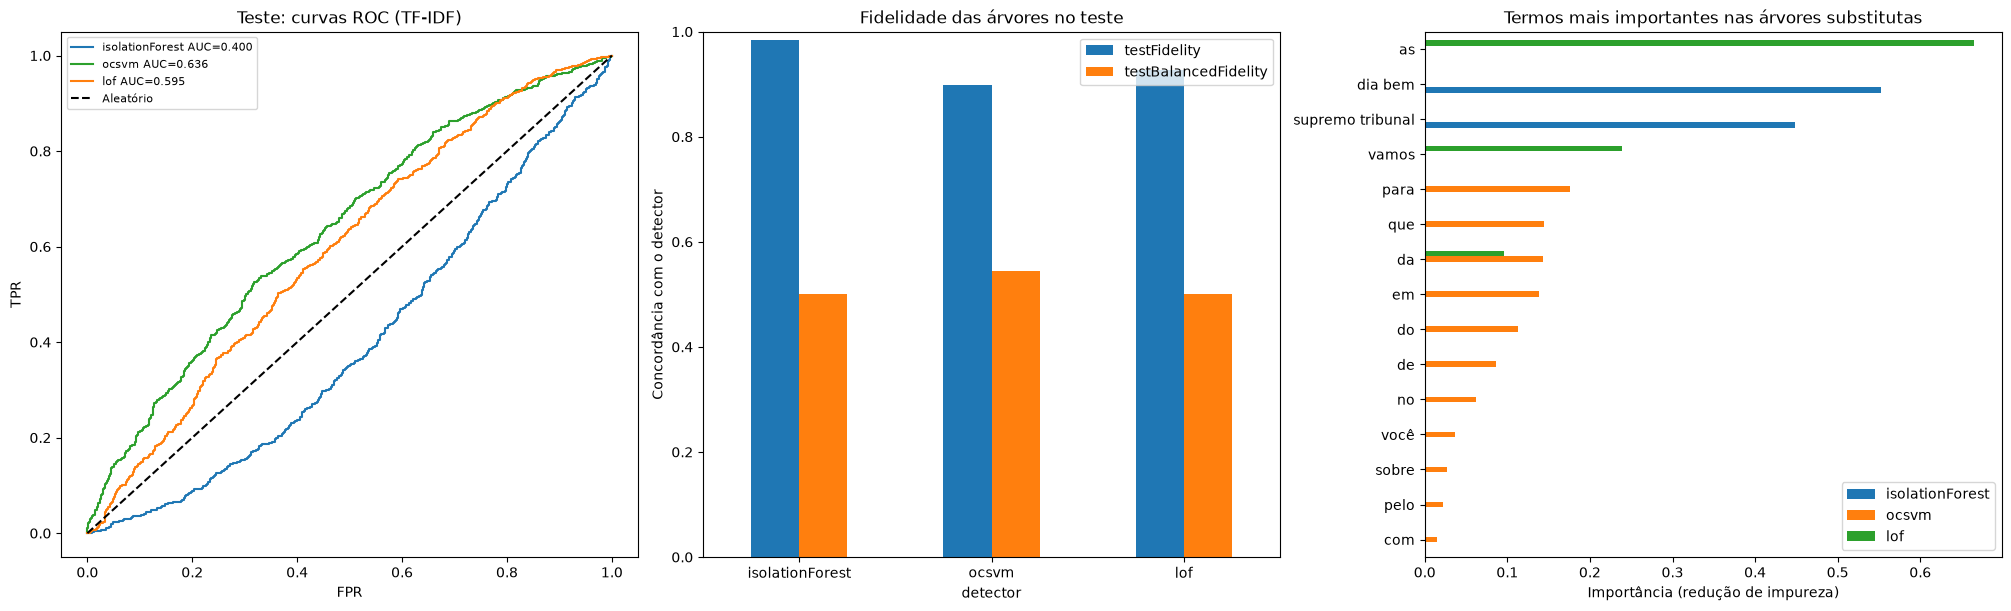

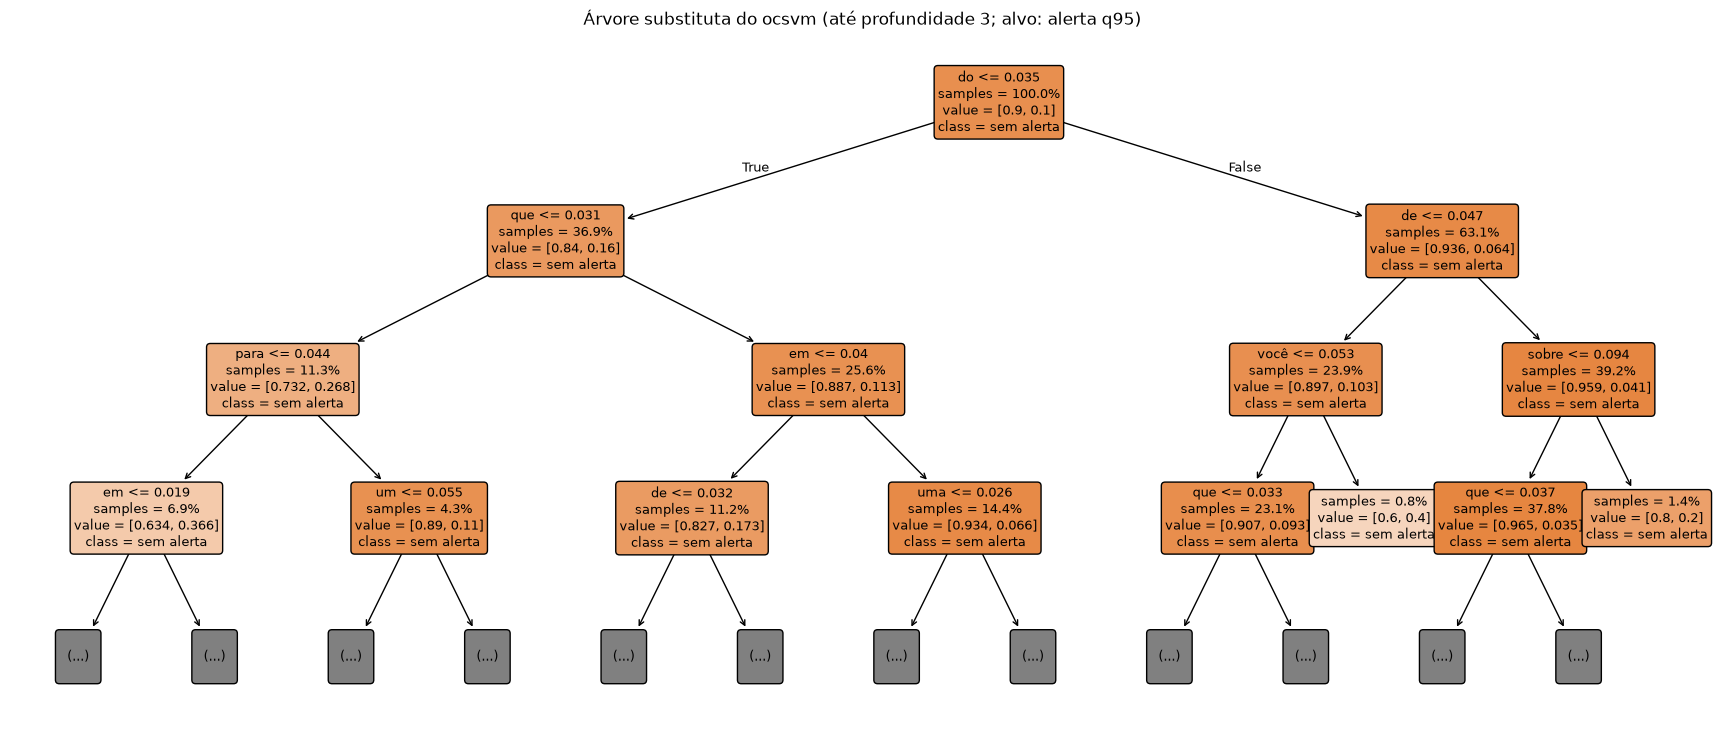

In [8]:
referenceDetector = detectorNames[
    validationResults.loc[validationResults["modelKey"].isin(selectedKeys.values())]
    .sort_values("validationRocAuc", ascending=False).iloc[0]["family"]
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for (name, result), color in zip(detectorResults.items(), ["tab:blue", "tab:green", "tab:orange"]):
    curveFpr, curveTpr, _ = roc_curve(testLabels, result["scores"])
    axes[0].plot(curveFpr, curveTpr, label=f"{name} AUC={result['q95Metrics']['rocAuc']:.3f}", color=color)
axes[0].plot([0, 1], [0, 1], "k--", label="Aleatório")
axes[0].set(title="Teste: curvas ROC (TF-IDF)", xlabel="FPR", ylabel="TPR")
axes[0].legend(fontsize=8)

fidelityResults[["testFidelity", "testBalancedFidelity"]].plot(
    kind="bar", ax=axes[1], ylim=(0, 1), title="Fidelidade das árvores no teste", rot=0,
)
axes[1].set(ylabel="Concordância com o detector")

importances = pd.DataFrame({name: tree.feature_importances_ for name, tree in surrogates.items()}, index=termNames)
importances.loc[importances.max(axis=1).nlargest(15).index].iloc[::-1].plot(
    kind="barh", ax=axes[2], title="Termos mais importantes nas árvores substitutas",
)
axes[2].set(xlabel="Importância (redução de impureza)")
plt.show()

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(surrogates[referenceDetector], feature_names=termNames, class_names=["sem alerta", "alerta"], max_depth=3,
          filled=True, rounded=True, impurity=False, proportion=True, fontsize=9, ax=ax)
ax.set_title(f"Árvore substituta do {referenceDetector} (até profundidade 3; alvo: alerta q95)")
plt.show()

## Discordâncias

Notícias de teste em que a regra e o detector de referência discordam: mostram onde as regras
simplificam demais o detector.

In [9]:
referenceResult = detectorResults[referenceDetector]
disagreementFrame = testFrame.assign(
    anomalyScore=referenceResult["scores"],
    detectorIsAnomaly=referenceResult["q95Flags"],
    ruleIsAnomaly=surrogates[referenceDetector].predict(testTerms),
).loc[lambda frame: frame["detectorIsAnomaly"] != frame["ruleIsAnomaly"]]

display(disagreementFrame.groupby(["label", "detectorIsAnomaly", "ruleIsAnomaly"]).size().rename("count").to_frame())
with pd.option_context("display.max_colwidth", 120):
    display(disagreementFrame.nlargest(10, "anomalyScore")[["id", "label", "anomalyScore", "detectorIsAnomaly", "ruleIsAnomaly", TEXT_COLUMN]])

count
label detectorIsAnomaly ruleIsAnomaly       
0     False             True               5
      True              False             29
1     False             True              31
      True              False            190

,id,label,anomalyScore,detectorIsAnomaly,ruleIsAnomaly,text
982,1623,1,0.074403,True,False,"""Senhor X"" é transferido para o ""Xilindró"" Bangu 9. ."
1019,1070,1,0.049752,True,False,"STF manda soltar ""homem da mala"". Edson Fachin, ministro do STF, mandou soltar o ex-deputado Rodrigo Rocha Loures."
806,3495,1,0.047273,True,False,Veja a lista dos 13 senadores que votaram contra a manutenção da prisão de Delcídio Amaral. .
738,1241,1,0.045350,True,False,"Aécio pediu R$ 2 milhões para Joesley e disse: ""A gente mata o entregador antes dele fazer a delação"". ."
988,884,1,0.043844,True,False,"Kim Jong-un prova que é lunático: ""Amo a paz, mas nenhum americano sairá vivo daqui"". . A afirmação foi divulgada p..."
1648,2421,1,0.043350,True,False,"Jornalista australiano destrói a imagem da Rio 2016: ""Favela olímpica, mar fedorento, dengue e bandidos"". Richard..."
2504,3262,1,0.042797,True,False,Paris vive momentos de pânico. Seis escolas são evacuadas por ameaças de bomba. Escolas secundárias foram evacuadas...
1774,2689,1,0.039332,True,False,Delação da OAS promete desmoronar o cenário político brasileiro. Léo Pinheiro [presidente da OAS] delatou Marina Si...
1760,1243,1,0.039236,True,False,Ministro do STF manda afastar Aécio do cargo de senador. .
1829,601,1,0.039115,True,False,"Avião da dupla Maiara e Maraisa sai da pista durante decolagem. Segundo informações do G1, o jato que levava a dupl..."


## Conclusão

In [10]:
referenceTable = ruleTables[referenceDetector]
alertRules = referenceTable.loc[referenceTable["prediction"].eq("alerta")]
referenceMetrics = referenceResult["q95Metrics"]
topAlertRule = alertRules.iloc[0] if not alertRules.empty else None
trivialSurrogates = [name for name, table in ruleTables.items() if not table["prediction"].eq("alerta").any()]
display(Markdown(f"""
Com **somente TF-IDF**, o detector de referência (**{referenceDetector}**, `{referenceResult['modelKey']}`)
obteve no teste ROC-AUC **{referenceMetrics['rocAuc']:.4f}**, AP **{referenceMetrics['averagePrecision']:.4f}**,
recall **{referenceMetrics['recall']:.2%}** e FPR **{referenceMetrics['fpr']:.2%}**.

Fidelidade das árvores no teste (acurácia / acurácia balanceada):
{", ".join(f"{name} {row.testFidelity:.2%} / {row.testBalancedFidelity:.2%}" for name, row in fidelityResults.iterrows())}.
A acurácia simples é inflada porque os detectores alertam pouco; acurácia balanceada perto de 50%
significa que a árvore não encontrou regra e só prevê "sem alerta"
(sem regra útil: **{", ".join(trivialSurrogates) or "nenhum"}**).
""" + (f"""A regra de alerta com maior suporte no {referenceDetector} é:

> **{topAlertRule['rule']}**

cobrindo **{topAlertRule['testSupport']}** notícias de teste, com **{topAlertRule['testFakeRate']:.2%}** de Fake.
""" if topAlertRule is not None else "") + """
Com só TF-IDF, os detectores treinados apenas em True separam pouco as classes: as Fake do Fake.br
tratam dos mesmos assuntos e usam o mesmo vocabulário das True. As regras que sobram descrevem o
comportamento dos detectores neste split (ex.: textos curtos, sem palavras funcionais comuns), não
causas de falsidade.
"""))


Com **somente TF-IDF**, o detector de referência (**ocsvm**, `ocsvm_nu_001`)
obteve no teste ROC-AUC **0.6364**, AP **0.8054**,
recall **11.94%** e FPR **4.17%**.

Fidelidade das árvores no teste (acurácia / acurácia balanceada):
isolationForest 98.37% / 50.00%, ocsvm 89.88% / 54.51%, lof 92.74% / 50.00%.
A acurácia simples é inflada porque os detectores alertam pouco; acurácia balanceada perto de 50%
significa que a árvore não encontrou regra e só prevê "sem alerta"
(sem regra útil: **isolationForest, lof**).
A regra de alerta com maior suporte no ocsvm é:

> **SE tfidf('do') <= 0.035 E tfidf('que') <= 0.031 E tfidf('para') <= 0.044 E não contém 'em' E tfidf('no') <= 0.052**

cobrindo **42** notícias de teste, com **85.71%** de Fake.

Com só TF-IDF, os detectores treinados apenas em True separam pouco as classes: as Fake do Fake.br
tratam dos mesmos assuntos e usam o mesmo vocabulário das True. As regras que sobram descrevem o
comportamento dos detectores neste split (ex.: textos curtos, sem palavras funcionais comuns), não
causas de falsidade.
